# Embeddings BERT Fine-tuned para Detección de Clickbait

Este notebook realiza:
1. Carga de librerías y datos
2. Uso del modelo distilbert-base-uncased
3. Extracción de embeddings
4. Visualizaciones UMAP

## 0. Configuración — Personaliza aquí los parámetros

In [1]:
# ============================================================
# RUTAS Y NOMBRES — editar aquí para nuevos datasets o modelos
# ============================================================

# Dataset
RUTA_DATOS = ["data/youtube_11s.json","data/youtube_cambio.json","data/youtube_covid.json",]

# Modelo base BERT
MODELO_BASE = "distilbert-base-uncased"

# Directorio de salida para gráficas
GRAFICAS_DIR = "img"

CAMPO_TITULO    = "Título"
CAMPO_CONTENIDO = "Contenido"
CAMPO_LABEL     = "Fake New"
CAMPO_CANAL = "Canal"
CAMPO_CATEGORIA = "Categoría"

# Hiperparámetros
MAX_LEN_TITULO    = 128
MAX_LEN_CONTENIDO = 512

EPOCHS_TITULO     = 3
EPOCHS_CONTENIDO  = 2

# Hiperparámetros UMAP
UMAP_N_NEIGHBORS = 30
UMAP_MIN_DIST    = 0.1

# Paleta de colores clickbait
COLOR_NO_CLICKBAIT = "#2E86AB"
COLOR_CLICKBAIT    = "#A23B72"

COLORES_PERIODICOS = {
    #"El País":              "#0066CC",
    #"El Mundo":             "#FF6600",
    #"ABC":                  "#CC0000",
    #"La Razón":             "#006633",
    #"20 Minutos":           "#0DCE1D",
    #"Público":              "#9900CC",
    #"eldiario.es":          "#00CCFF",
    #"Huffington Post":      "#FF00AA",
    #"El Confidencial":      "#CC9900",
    #"Mediterráneo Digital": "#009999",
}

COLORES_CATEGORIAS = {
    "11s":        "#E63946",
    "Cambio climático": "#2A9D8F",
    "Covid":            "#E9C46A",
}

## 1. Librerías

In [ ]:
%pip install datasets

In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from umap import UMAP
from matplotlib.patches import Patch
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from datasets import Dataset

os.makedirs(GRAFICAS_DIR, exist_ok=True)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Carga de datos

In [3]:
import json

noticias = []
for ruta in RUTA_DATOS:
    with open(ruta, "r", encoding="utf-8") as f:
        noticias.extend(json.load(f))

print(f"Vídeos cargados: {len(noticias)}")
print(f"Campos disponibles: {list(noticias[0].keys())}")

Vídeos cargados: 147
Campos disponibles: ['Link', 'Canal', 'Fecha', 'Título', 'Subtítulo', 'Categoría', 'Contenido', 'Fake New', 'Probabilidad Fake New']


## 3. Modelo destilBERT

### 3.1 Carga del Modelo

In [4]:
from transformers import AutoTokenizer, AutoModel

# Cargamos directamente el modelo base sin fine-tuning
tokenizer_titulo    = AutoTokenizer.from_pretrained(MODELO_BASE)
model_titulo        = AutoModel.from_pretrained(MODELO_BASE)
model_titulo.eval()

tokenizer_contenido = tokenizer_titulo   # mismo tokenizer para ambos
model_contenido     = model_titulo       # mismo modelo para ambos

print("Modelo base cargado. No se realiza fine-tuning (dataset pequeño).")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo base cargado. No se realiza fine-tuning (dataset pequeño).


In [5]:
def preparar_dataset(noticias, campo_texto, campo_label=CAMPO_LABEL, test_size=0.2, seed=42):
    """Crea un HuggingFace Dataset con train/test split."""
    datos = {
        "text":  [n.get(campo_texto, "") for n in noticias],
        "label": [1 if n.get(campo_label) else 0 for n in noticias],
    }
    return Dataset.from_dict(datos).train_test_split(test_size=test_size, seed=seed)


def tokenizar_dataset(datasets, tokenizer, max_length):
    """Tokeniza el dataset completo."""
    def _tokenize(examples):
        return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=max_length)
    return datasets.map(_tokenize, batched=True)

## 4. Extracción de embeddings

In [6]:
def obtener_embeddings(textos, tokenizer, model, max_length, batch_size=32):
    """
    Extrae el embedding [CLS] para una lista de textos.
    Procesa en batches para no saturar la GPU/CPU.

    Returns
    -------
    np.ndarray  shape (n_textos, hidden_size)
    """
    all_embeddings = []

    for i in range(0, len(textos), batch_size):
        batch = textos[i: i + batch_size]
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        with torch.no_grad():
            outputs = model(**inputs)
        cls = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls)

        if (i // batch_size + 1) % 10 == 0:
            print(f"  Batch {i // batch_size + 1}/{len(textos) // batch_size + 1}")

    return np.vstack(all_embeddings)

In [7]:
titulos    = [n.get(CAMPO_TITULO, "")    for n in noticias]
contenidos = [n.get(CAMPO_CONTENIDO, "") for n in noticias]
labels     = [n.get(CAMPO_LABEL, False)  for n in noticias]
periodicos = [n.get(CAMPO_CANAL, "")     for n in noticias]
categorias = [n.get(CAMPO_CATEGORIA, "") for n in noticias]

print("Extrayendo embeddings de títulos...")
embeddings_titulo = obtener_embeddings(titulos, tokenizer_titulo, model_titulo, MAX_LEN_TITULO)

print("\nExtrayendo embeddings de contenido...")
embeddings_contenido = obtener_embeddings(contenidos, tokenizer_contenido, model_contenido, MAX_LEN_CONTENIDO)

print(f"\nShape títulos:   {embeddings_titulo.shape}")
print(f"Shape contenido: {embeddings_contenido.shape}")

Extrayendo embeddings de títulos...

Extrayendo embeddings de contenido...

Shape títulos:   (147, 768)
Shape contenido: (147, 768)


## 5. Reducción UMAP y visualizaciones

Las funciones de graficado reciben los embeddings y metadatos como parámetros, por lo que son fácilmente reutilizables con nuevos datos.

### 5.1 Funciones de visualización

In [8]:
def reducir_umap(embeddings, n_neighbors=UMAP_N_NEIGHBORS, min_dist=UMAP_MIN_DIST, random_state=42):
    """Reduce embeddings a 2D con UMAP."""
    reducer = UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="cosine",
        random_state=random_state,
    )
    return reducer.fit_transform(embeddings)


def _asignar_colores_faltantes(elementos, paleta):
    """Añade colores aleatorios a la paleta para elementos no definidos."""
    for elem in set(elementos):
        if elem not in paleta:
            paleta[elem] = f"#{np.random.randint(0, 0xFFFFFF):06x}"
    return paleta


def graficar_umap_FakeNews(embeddings_2d, labels, titulo_grafica, guardar_como=None):
    """
    Jointplot UMAP coloreado por Fake News / No Fake News.

    Parámetros
    ----------
    embeddings_2d   : np.ndarray (N, 2)
    labels          : list[bool]  — True = clickbait
    titulo_grafica  : str
    guardar_como    : str|None    — ruta de guardado, ej. "img/titulo_FakeNews.png"
    """
    df = pd.DataFrame({
        "UMAP 1":   embeddings_2d[:, 0],
        "UMAP 2":   embeddings_2d[:, 1],
        "Fake News": ["Fake News" if x else "No Fake News" for x in labels],
    })

    sns.set_style("whitegrid")
    palette = {"No Fake News": COLOR_NO_CLICKBAIT, "Fake News": COLOR_CLICKBAIT}

    g = sns.jointplot(
        data=df, x="UMAP 1", y="UMAP 2",
        hue="Fake News", kind="scatter",
        alpha=0.55, palette=palette,
        height=10, space=0.15, s=50,
        marginal_kws=dict(fill=True, common_norm=False, alpha=0.4),
    )

    g.fig.suptitle(titulo_grafica, fontsize=16, fontweight="bold", y=0.995)
    g.set_axis_labels("UMAP Dimensión 1", "UMAP Dimensión 2", fontsize=12, fontweight="bold")
    g.ax_joint.grid(True, alpha=0.3, linestyle="--", linewidth=0.5)

    plt.tight_layout()
    if guardar_como:
        plt.savefig(guardar_como, dpi=300, bbox_inches="tight")
        print(f"Guardado: {guardar_como}")
    plt.show()


def graficar_umap_categoria(embeddings_2d, labels, categorias, titulo_grafica, guardar_como=None):
    """
    JointGrid UMAP con KDE de clickbait de fondo y scatter por categoría.

    Parámetros
    ----------
    embeddings_2d : np.ndarray (N, 2)
    labels        : list[bool]   — True = clickbait
    categorias    : list[str]
    titulo_grafica: str
    guardar_como  : str|None
    """
    paleta_cat = _asignar_colores_faltantes(categorias, dict(COLORES_CATEGORIAS))
    palette_cb = {"No Fake News": COLOR_NO_CLICKBAIT, "Fake News": COLOR_CLICKBAIT}

    df = pd.DataFrame({
        "UMAP 1":    embeddings_2d[:, 0],
        "UMAP 2":    embeddings_2d[:, 1],
        "Fake News": ["Fake News" if x else "No Fake News" for x in labels],
        "Categoría": categorias,
    })

    sns.set_style("whitegrid")
    g = sns.JointGrid(data=df, x="UMAP 1", y="UMAP 2", height=10, space=0.15)

    # KDE de fondo por clickbait
    for cb, color in palette_cb.items():
        subset = df[df["Fake News"] == cb]
        sns.kdeplot(data=subset, x="UMAP 1", y="UMAP 2",
                    fill=True, alpha=0.8, levels=6, color=color, ax=g.ax_joint)

    # Scatter por categoría
    for cat in df["Categoría"].unique():
        subset = df[df["Categoría"] == cat]
        g.ax_joint.scatter(
            subset["UMAP 1"], subset["UMAP 2"],
            label=cat, alpha=0.75, s=50,
            color=paleta_cat[cat], edgecolors="black", linewidth=0.4,
        )

    # Marginales por categoría
    for cat in df["Categoría"].unique():
        subset = df[df["Categoría"] == cat]
        sns.kdeplot(data=subset, x="UMAP 1", fill=True, alpha=0.35,
                    color=paleta_cat[cat], ax=g.ax_marg_x)
        sns.kdeplot(data=subset, y="UMAP 2", fill=True, alpha=0.35,
                    color=paleta_cat[cat], ax=g.ax_marg_y)

    g.fig.suptitle(titulo_grafica, fontsize=18, fontweight="bold", y=1.02)
    g.set_axis_labels("UMAP Dimensión 1", "UMAP Dimensión 2", fontsize=13, fontweight="bold")

    legend_cat = g.ax_joint.legend(
        title="Categoría", fontsize=10, title_fontsize=11, loc="upper right", frameon=True
    )
    g.ax_joint.add_artist(legend_cat)

    handles_cb = [
        Patch(facecolor=COLOR_NO_CLICKBAIT, edgecolor="none", alpha=0.8, label="No Fake News"),
        Patch(facecolor=COLOR_CLICKBAIT,    edgecolor="none", alpha=0.8, label="Fake News"),
    ]
    g.ax_joint.legend(handles=handles_cb, title="Fake News", fontsize=10,
                      title_fontsize=11, loc="upper left", frameon=True)

    g.ax_joint.grid(True, alpha=0.3, linestyle="--", linewidth=0.5)
    sns.despine()
    plt.tight_layout()

    if guardar_como:
        plt.savefig(guardar_como, dpi=300, bbox_inches="tight")
        print(f"Guardado: {guardar_como}")
    plt.show()

### 5.2 Reducción UMAP

In [9]:
print("Calculando UMAP para títulos...")
umap_titulo = reducir_umap(embeddings_titulo)

print("Calculando UMAP para contenido...")
umap_contenido = reducir_umap(embeddings_contenido)

print("UMAP completado.")

Calculando UMAP para títulos...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Calculando UMAP para contenido...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP completado.


### 5.3 Espacios Embebidos de Títulos — Análisis UMAP

Guardado: img/UMAP_titulos_FakeNews.png


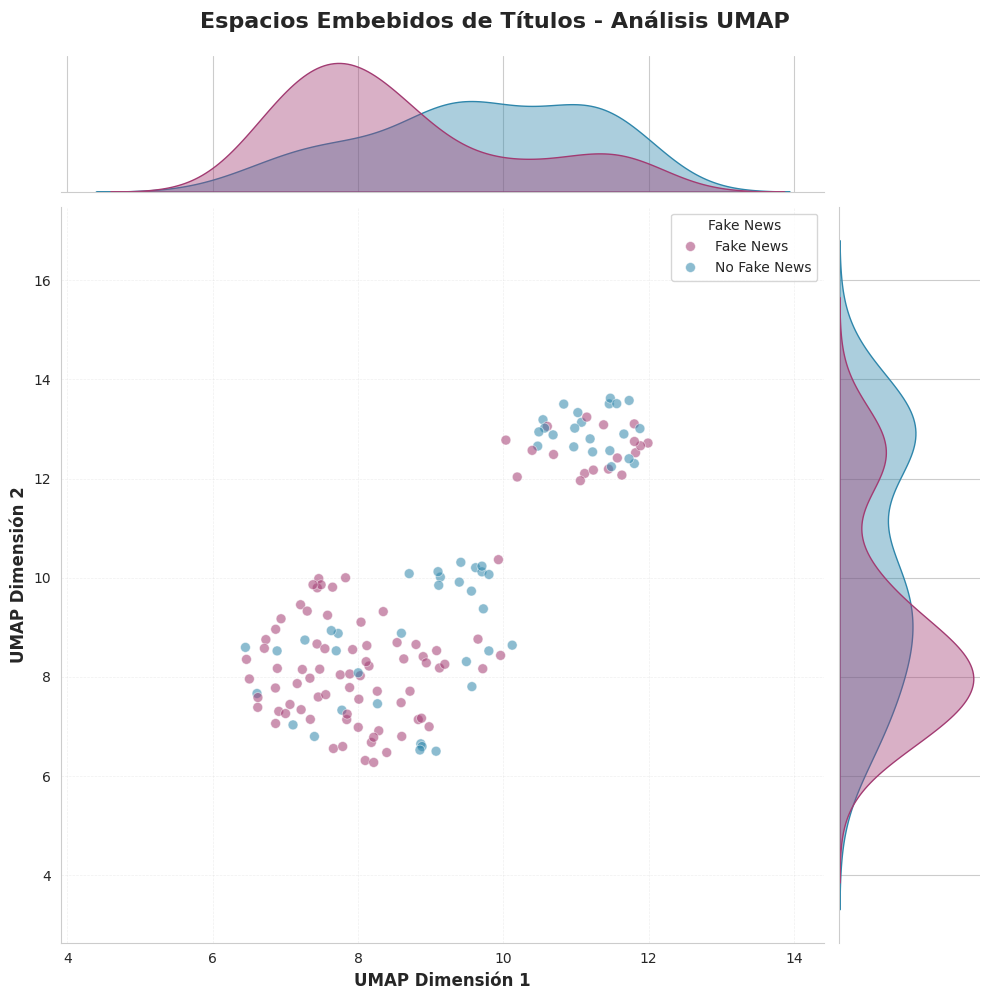

In [10]:
graficar_umap_FakeNews(
    umap_titulo,
    labels,
    titulo_grafica="Espacios Embebidos de Títulos - Análisis UMAP",
    guardar_como=f"{GRAFICAS_DIR}/UMAP_titulos_FakeNews.png",
)

### 5.4 Espacios Embebidos de Contenido — Análisis UMAP

Guardado: img/UMAP_contenido_FakeNews.png


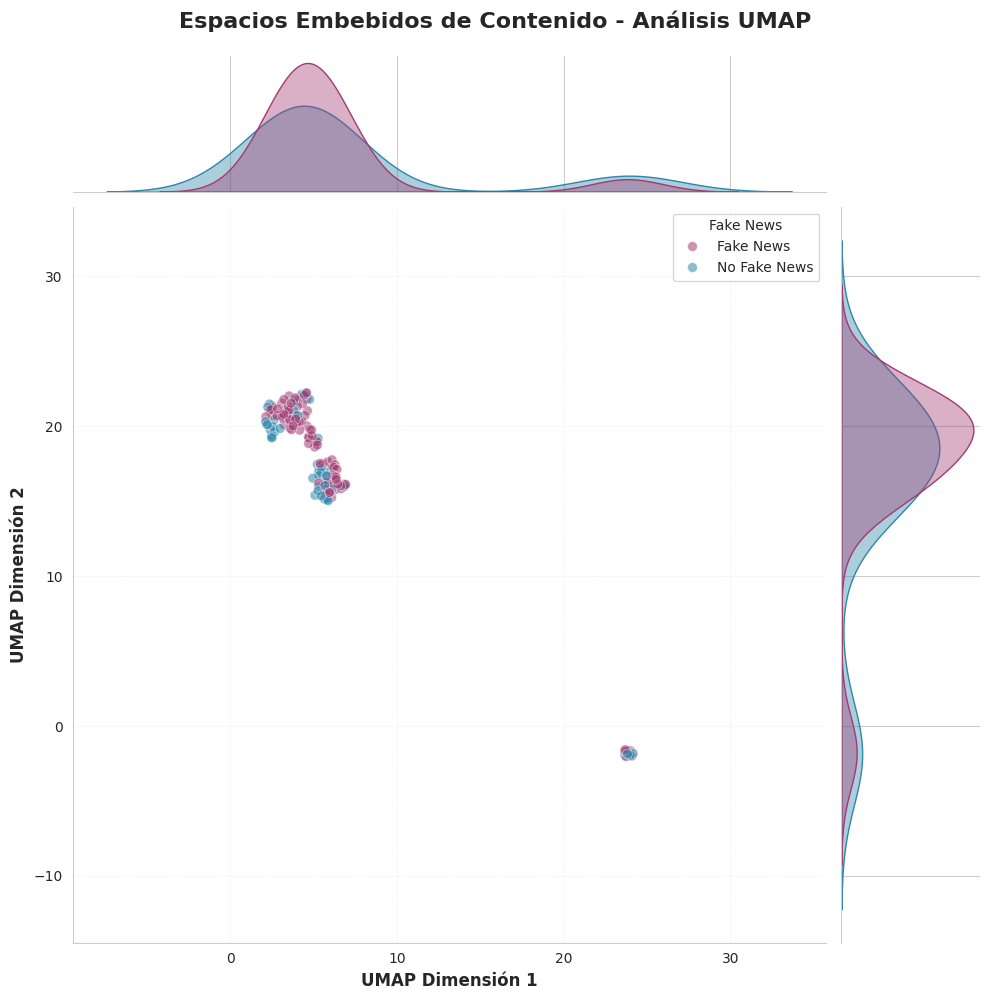

In [11]:
graficar_umap_FakeNews(
    umap_contenido,
    labels,
    titulo_grafica="Espacios Embebidos de Contenido - Análisis UMAP",
    guardar_como=f"{GRAFICAS_DIR}/UMAP_contenido_FakeNews.png",
)

### 5.7 Espacios Embebidos de Títulos — UMAP (KDE + categoría)

Guardado: img/UMAP_titulos_categoria_FakeNews.png


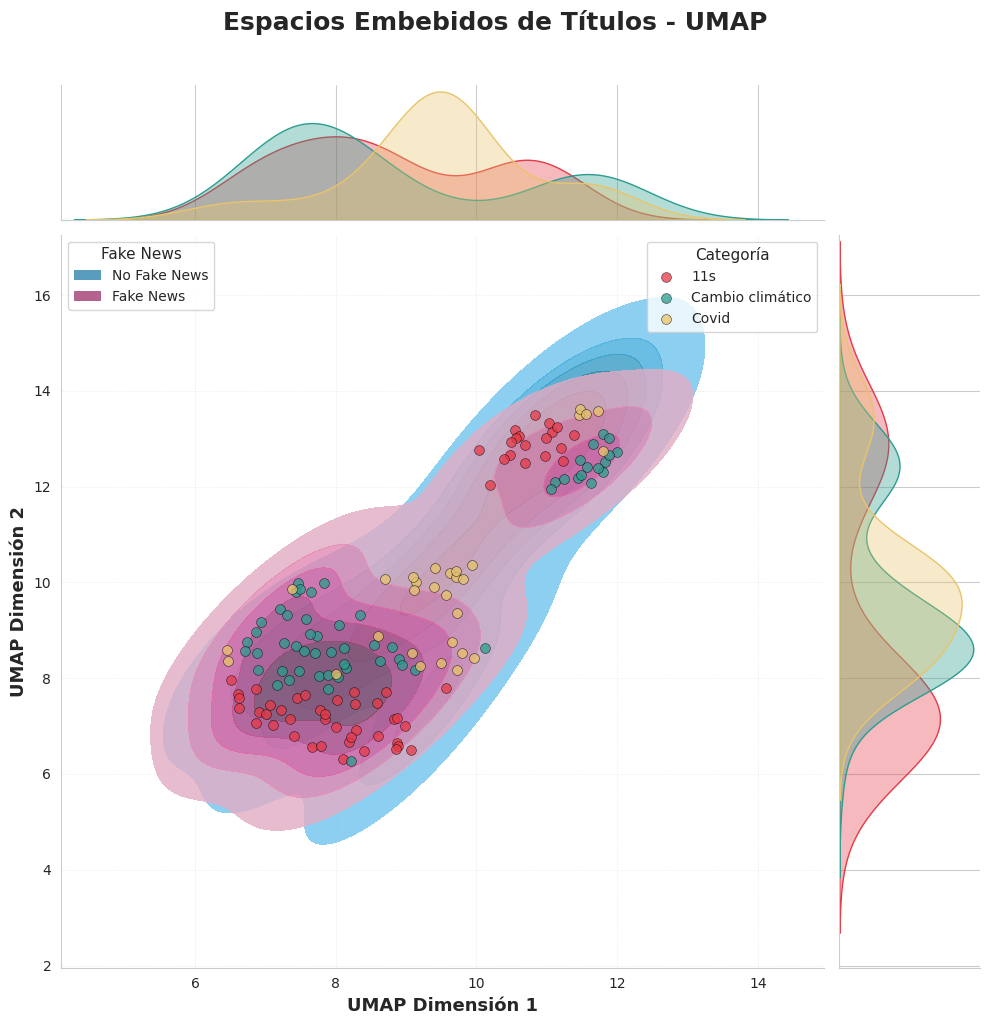

In [12]:
graficar_umap_categoria(
    umap_titulo,
    labels,
    categorias,
    titulo_grafica="Espacios Embebidos de Títulos - UMAP",
    guardar_como=f"{GRAFICAS_DIR}/UMAP_titulos_categoria_FakeNews.png",
)

### 5.8 Espacios Embebidos de Contenido — UMAP (KDE + categoría)

Guardado: img/UMAP_contenido_categoria_FakeNews.png


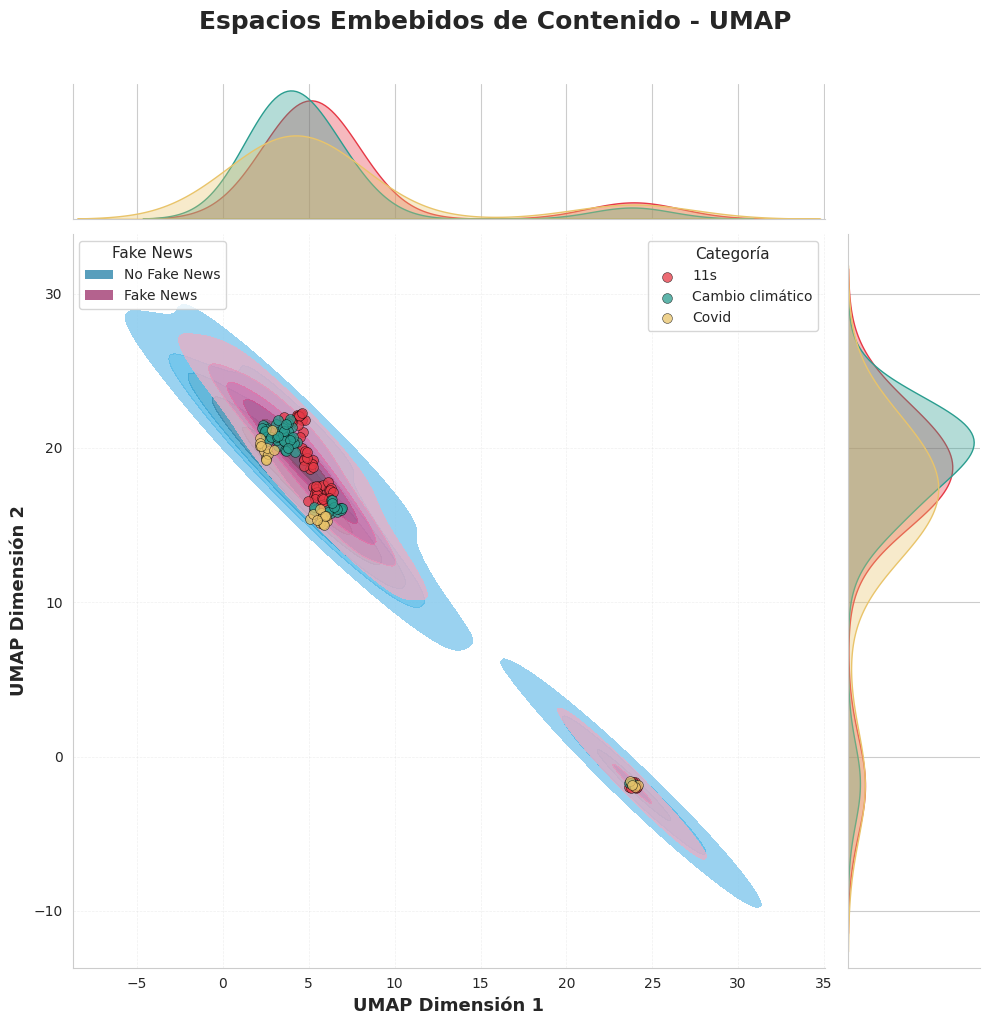

In [13]:
graficar_umap_categoria(
    umap_contenido,
    labels,
    categorias,
    titulo_grafica="Espacios Embebidos de Contenido - UMAP",
    guardar_como=f"{GRAFICAS_DIR}/UMAP_contenido_categoria_FakeNews.png",
)